<a href="https://colab.research.google.com/github/hunkim98/earth_science/blob/main/lectures/EPS210_Lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Harvard EPS-210 AI for Earth and Planetary Science

Instructor: Mostafa Mouasvi

# **Lab 7**:


---


<div style="background: linear-gradient(135deg, #1b5e20 0%, #1a237e 100%); padding: 30px; border-radius: 10px; color: white;">
<h1 style="color: white; margin: 0;">🌍 GraphCast-Style GNN for Atmospheric CO₂ Transport</h1>
<h2 style="color: #c8e6c9; margin-top: 10px;">Graph Neural Network Emulation of Eulerian Tracer Transport</h2>
<p style="color: #e0e0e0; font-size: 14px;">

## 📋 Lab Overview

| | |
|---|---|
| **Topic** | Neural network emulation of atmospheric CO₂ transport using Graph Neural Networks |
| **Architecture** | GraphCast-style Encode–Process–Decode GNN on an icosahedral mesh |
| **Inspiration** | [NeuralTransport](https://github.com/vitusbenson/neural_transport) (Benson et al., 2025) — CarbonBench benchmark |
| **Framework** | PyTorch + PyTorch Geometric |
| **Duration** | ~3 hours |

### Learning Objectives

1. Understand **offline atmospheric tracer transport** — how CO₂ is advected by winds through the 3D atmosphere
2. Build an **icosahedral mesh** from a latitude–longitude grid, the same representation used by GraphCast for weather prediction
3. Implement the **Encode–Process–Decode** GNN architecture with message passing on the icosahedral mesh
4. Apply physics-based training tricks from Benson et al. (2025): **CentFlux** (CO₂ centering + flux injection) and **SpecLoss** (spectral power spectrum loss)
5. Implement a **mass fixer** to ensure global CO₂ mass conservation — a hard physical constraint
6. Compare GraphCast GNN against a U-Net baseline for multi-step CO₂ transport rollouts

### Key References

- Benson, V. et al. (2025). *Atmospheric Transport Modeling of CO₂ with Neural Networks.* JAMES, 17(2). [arXiv:2408.11032](https://arxiv.org/abs/2408.11032)
- [NeuralTransport code](https://github.com/vitusbenson/neural_transport) — Python library for training neural network emulators of atmospheric transport
- [CarbonBench](https://github.com/vitusbenson/carbonbench) — Systematic benchmark for ML emulators of Eulerian atmospheric transport
- Lam, R. et al. (2023). *Learning Skillful Medium-range Global Weather Forecasting.* Science, 382(6677).
- Keisler, R. (2022). *Forecasting Global Weather with Graph Neural Networks.* arXiv:2202.07575

---
# 1. Background

## 1.1 The Atmospheric CO₂ Transport Problem

Accurately modeling how CO₂ moves through the atmosphere is essential for greenhouse gas monitoring and verification support systems under international climate agreements. The task is **offline tracer transport**: given wind fields (from ERA5 reanalysis) and surface CO₂ fluxes (biosphere, ocean, anthropogenic emissions, fires), predict how the 3D CO₂ concentration field evolves over time.

Mathematically, the continuity equation governs tracer transport:

$$\frac{\partial c}{\partial t} + \nabla \cdot (\mathbf{u} c) = S$$

where $c$ is the CO₂ mixing ratio, $\mathbf{u}$ is the 3D wind field, and $S$ represents surface sources/sinks. Traditional transport models like TM5 (used in CarbonTracker) solve this equation numerically, but require small time steps for stability (≤90 min) and are IO-intensive when loading ERA5 wind fields.

## 1.2 Why Graph Neural Networks?

Benson et al. (2025) compared four architectures for CO₂ transport emulation: U-Net, **GraphCast**, SFNO, and SwinTransformer. Each maps to a different numerical method:

| Architecture | Analogy | Mesh Type |
|---|---|---|
| U-Net | Finite differences on regular grid | Lat–lon grid |
| **GraphCast** | **Finite differences on icosahedral mesh** | **Icosahedral → lat–lon** |
| SFNO | Pseudo-spectral solver | Spherical harmonics |
| SwinTransformer | Brute-force attention | Patch-based windows |

GraphCast uses an **Encode–Process–Decode** layout (Battaglia et al., 2018):
- **Encoder**: Maps lat–lon grid → icosahedral mesh + projects to latent space
- **Processor**: Message passing on the icosahedral mesh (local stencils on the sphere)
- **Decoder**: Maps icosahedral mesh → lat–lon grid + projects back to physical space

The icosahedral mesh avoids the pole singularity problem of regular lat–lon grids and provides quasi-uniform resolution over the globe.

## 1.3 Key Training Innovations (Benson et al., 2025)

Two physics-based tricks are critical for stable long-term CO₂ transport:

**CentFlux** — Center the CO₂ field by subtracting the global mean before feeding it to the network, then add prescribed surface fluxes to the lowest vertical layer. This decouples the network from the secular rise in atmospheric CO₂ (~2.5 ppm/year), preventing distribution shift.

**SpecLoss** — An additional loss term that penalizes deviations in the spherical harmonic power spectrum between prediction and target. This prevents the model from losing energy at small spatial scales.

**Mass Fixer** — Post-hoc rescaling to ensure global CO₂ mass is exactly conserved. The total mass of CO₂ in the atmosphere must only change due to surface fluxes — any other mass change is a numerical artifact.

---
# 2. Part 1 — Environment Setup & Data

In [28]:
#@title 📦 Install and Import Dependencies { display-mode: "form" }
!pip install -q torch torchvision torchaudio
!pip install -q torch-geometric
!pip install -q matplotlib tqdm scipy


import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1' # Force PyTorch to not see any GPUs

import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.spatial import SphericalVoronoi, ConvexHull
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.data import Data, Batch
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import warnings; warnings.filterwarnings('ignore')

# Force DEVICE to 'cpu' for debugging, regardless of CUDA availability
DEVICE = 'cuda'
print(f'Device: {DEVICE}')
print(f'torch.cuda.is_available(): {torch.cuda.is_available()}')
if DEVICE == 'cuda': print(f'GPU: {torch.cuda.get_device_name(0)}')

torch.cuda.is_available(): False


## 2.1 Building the Icosahedral Mesh

<p align="center">
  <img src="https://github.com/smousavi05/Harvard-EPS-210/raw/main/figures/icosahedral_mesh.png" width="900">
</p>

Think of a standard map or a globe with traditional latitude and longitude lines. As those vertical lines (meridians) move toward the North and South Poles, they get closer and closer together until they all meet at a single point.

In computer modeling, this creates a "crowding" problem. The grid squares near the equator are huge, while the ones near the poles are tiny slivers. This makes calculations uneven and computationally "expensive" at the top and bottom of the world.

**The Icosahedral Solution**

GraphCast avoids this by using an icosahedral mesh. Instead of a grid of rectangles, it wraps the Earth in a web of triangles (starting from a 20-sided shape called an icosahedron).

  * **Uniformity:** Unlike the latitude-longitude grid, these triangles stay roughly the same size and shape no matter where they are on the planet.

  * **No "Pole Problem":** Because the resolution is nearly the same everywhere, the model doesn't have to deal with converging lines at the poles.

  * **The Analogy:** Modern weather models like ICON and MPAS use this same geometric trick. It's essentially the difference between trying to wrap a sphere in flat graph paper (which wrinkles at the ends) versus building a soccer ball out of equal-sized panels.

**Why it Matters**
By using this mesh, GraphCast can "see" the entire world with the same level of detail. It treats a storm over the Arctic with the same mathematical precision as a hurricane in the Atlantic, without wasting computing power on the overlapping lines of a traditional map.

We build a multi-resolution icosahedral mesh by recursively subdividing the faces of an icosahedron.

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def create_icosahedron():
    """Create the 12 vertices and 20 faces of a regular icosahedron."""
    phi = (1 + np.sqrt(5)) / 2  # Golden ratio
    verts = np.array([
        [-1,  phi, 0], [ 1,  phi, 0], [-1, -phi, 0], [ 1, -phi, 0],
        [ 0, -1,  phi], [ 0,  1,  phi], [ 0, -1, -phi], [ 0,  1, -phi],
        [ phi, 0, -1], [ phi, 0,  1], [-phi, 0, -1], [-phi, 0,  1],
    ], dtype=np.float64)

    # Normalize to unit sphere
    verts /= np.linalg.norm(verts, axis=1, keepdims=True)

    faces = [
        (0,11,5),(0,5,1),(0,1,7),(0,7,10),(0,10,11),
        (1,5,9),(5,11,4),(11,10,2),(10,7,6),(7,1,8),
        (3,9,4),(3,4,2),(3,2,6),(3,6,8),(3,8,9),
        (4,9,5),(2,4,11),(6,2,10),(8,6,7),(9,8,1),
    ]
    return verts, faces


def subdivide_icosphere(verts, faces, n_subdivisions=2):
    """Recursively subdivide each triangle into 4 smaller triangles."""
    for _ in range(n_subdivisions):
        new_faces = []
        edge_midpoints = {}
        for v0, v1, v2 in faces:
            mids = []
            for (a, b) in [(v0,v1), (v1,v2), (v0,v2)]:
                edge = tuple(sorted([a, b]))
                if edge not in edge_midpoints:
                    mid = (verts[a] + verts[b]) / 2
                    mid /= np.linalg.norm(mid)
                    edge_midpoints[edge] = len(verts)
                    verts = np.vstack([verts, mid])
                mids.append(edge_midpoints[edge])
            m01, m12, m02 = mids
            new_faces += [(v0, m01, m02), (v1, m12, m01),
                          (v2, m02, m12), (m01, m12, m02)]
        faces = new_faces
    return verts, faces


def build_icosahedral_mesh(n_subdivisions=3):
    """Build mesh vertices, edges, and face connectivity."""
    verts, faces = create_icosahedron()
    verts, faces = subdivide_icosphere(verts, faces, n_subdivisions)

    # Build edge list from faces
    edges = set()
    for v0, v1, v2 in faces:
        for a, b in [(v0,v1), (v1,v2), (v0,v2)]:
            edges.add((min(a,b), max(a,b)))
    edge_index = np.array(list(edges)).T  # [2, n_edges]

    # Make bidirectional
    edge_index = np.concatenate([edge_index, edge_index[::-1]], axis=1)

    # Convert to lat/lon
    x, y, z = verts.T
    lat = np.degrees(np.arcsin(np.clip(z, -1, 1)))
    lon = np.degrees(np.arctan2(y, x))

    print(f'Icosahedral mesh (subdivisions={n_subdivisions}):')
    print(f'  Vertices: {len(verts)}')
    print(f'  Edges:    {edge_index.shape[1]} (bidirectional)')
    print(f'  Faces:    {len(faces)}')
    return verts, edge_index, lat, lon, faces


n_sub = 3
ico_verts, ico_edges, ico_lat, ico_lon, ico_faces = build_icosahedral_mesh(n_subdivisions=n_sub)


Icosahedral mesh (subdivisions=3):
  Vertices: 642
  Edges:    3840 (bidirectional)
  Faces:    1280


Icosahedral mesh (subdivisions=3):
  Vertices: 642
  Edges:    3840 (bidirectional)
  Faces:    1280


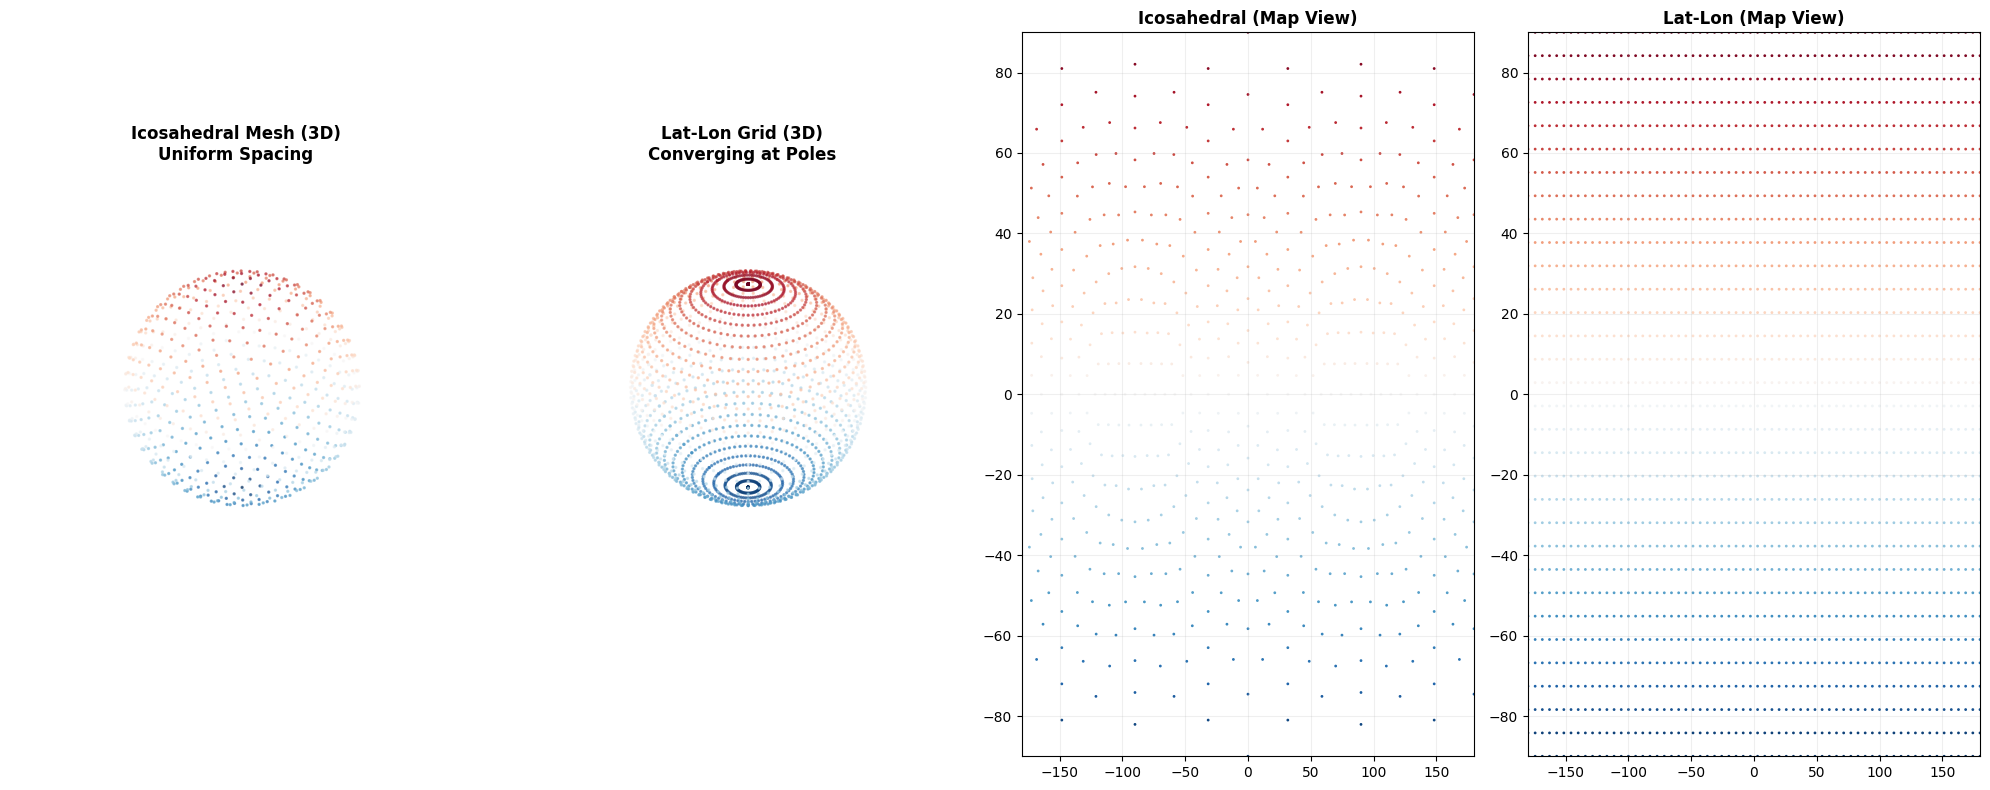

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- (Insert your create_icosahedron, subdivide_icosphere, and build_mesh functions here) ---

# 1. Generate Mesh Data
ico_verts, ico_edges, ico_lat, ico_lon, ico_faces = build_icosahedral_mesh(n_subdivisions=3)

# 2. Generate Regular Lat-Lon Grid Data
n_lat, n_lon = 32, 64
lats_vec = np.linspace(-np.pi/2, np.pi/2, n_lat)
lons_vec = np.linspace(-np.pi, np.pi, n_lon)
lon_g, lat_g = np.meshgrid(lons_vec, lats_vec)

# Convert Lat-Lon Grid to 3D Cartesian for the sphere
x_g = np.cos(lat_g) * np.cos(lon_g)
y_g = np.cos(lat_g) * np.sin(lon_g)
z_g = np.sin(lat_g)

# 3. Visualization
fig = plt.figure(figsize=(20, 8))

# --- PLOT 1: Icosahedral Mesh (3D) ---
ax1 = fig.add_subplot(141, projection='3d')
ax1.scatter(ico_verts[:, 0], ico_verts[:, 1], ico_verts[:, 2],
            s=2, c=ico_lat, cmap='RdBu_r', alpha=0.6)
ax1.set_title('Icosahedral Mesh (3D)\nUniform Spacing', fontweight='bold')
ax1.set_axis_off()
ax1.set_box_aspect([1,1,1])

# --- PLOT 2: Lat-Lon Grid (3D) ---
# THIS SHOWS THE CONVERGING POINTS
ax2 = fig.add_subplot(142, projection='3d')
ax2.scatter(x_g.ravel(), y_g.ravel(), z_g.ravel(),
            s=2, c=np.degrees(lat_g.ravel()), cmap='RdBu_r', alpha=0.6)
ax2.set_title('Lat-Lon Grid (3D)\nConverging at Poles', fontweight='bold')
ax2.set_axis_off()
ax2.set_box_aspect([1,1,1])

# --- PLOT 3: Icosahedral Mesh (2D Map) ---
ax3 = fig.add_subplot(143)
ax3.scatter(ico_lon, ico_lat, s=1, c=ico_lat, cmap='RdBu_r')
ax3.set_title('Icosahedral (Map View)', fontweight='bold')
ax3.set_xlim(-180, 180); ax3.set_ylim(-90, 90); ax3.grid(alpha=0.2)

# --- PLOT 4: Lat-Lon Grid (2D Map) ---
ax4 = fig.add_subplot(144)
ax4.scatter(np.degrees(lon_g.ravel()), np.degrees(lat_g.ravel()),
            s=1, c=np.degrees(lat_g.ravel()), cmap='RdBu_r')
ax4.set_title('Lat-Lon (Map View)', fontweight='bold')
ax4.set_xlim(-180, 180); ax4.set_ylim(-90, 90); ax4.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Plot 2 (Lat-Lon 3D): Look at the "North Pole" of the sphere. You will see the colored dots practically touching each other. This is the Pole Crowding problem. It wastes computing power because you're calculating weather for thousands of tiny slivers that all cover the same spot.

Plot 1 (Icosahedral 3D): The dots are evenly distributed. No matter how much you rotate the sphere, the distance between neighbors is almost identical.

## 2.2 Grid-to-Mesh and Mesh-to-Grid Mapping

GraphCast needs to map between the **regular lat–lon grid** (where input data lives) and the **icosahedral mesh** (where message passing occurs). This is done by finding nearest-neighbor correspondences.

In [6]:
# Build the regular lat-lon grid (CarbonBench LowRes: 64 lat × 128 lon)
N_LAT, N_LON = 32, 64
N_VERT = 10

grid_lats = np.linspace(-87.19, 87.19, N_LAT)  # Avoid exact poles
grid_lons = np.linspace(-180, 177.19, N_LON)
grid_lon_2d, grid_lat_2d = np.meshgrid(grid_lons, grid_lats)
grid_points = np.stack([grid_lat_2d.ravel(), grid_lon_2d.ravel()], axis=-1)

# Convert grid points to 3D Cartesian for nearest-neighbor matching
def latlon_to_xyz(lat, lon):
    lat_r, lon_r = np.radians(lat), np.radians(lon)
    return np.stack([np.cos(lat_r)*np.cos(lon_r),
                     np.cos(lat_r)*np.sin(lon_r),
                     np.sin(lat_r)], axis=-1)

grid_xyz = latlon_to_xyz(grid_points[:, 0], grid_points[:, 1])

# For each grid point, find nearest icosahedral vertex (encoder mapping)
from scipy.spatial import cKDTree
ico_tree = cKDTree(ico_verts)
_, grid_to_ico = ico_tree.query(grid_xyz)  # [N_LAT*N_LON] → ico vertex index

# For each ico vertex, find nearest grid point (decoder mapping)
grid_tree = cKDTree(grid_xyz)
_, ico_to_grid = grid_tree.query(ico_verts)  # [N_ICO] → grid flat index

# Build encoder/decoder edge lists for PyG
# Encoder: grid → ico (bipartite edges)
enc_src = np.arange(len(grid_xyz))
enc_dst = grid_to_ico
encoder_edges = np.stack([enc_src, enc_dst])  # [2, N_grid]

# Decoder: ico → grid (bipartite edges)
dec_src = np.arange(len(ico_verts))
dec_dst = ico_to_grid
decoder_edges = np.stack([dec_src, dec_dst])  # [2, N_ico]

print(f'Grid:  {N_LAT}×{N_LON} = {N_LAT*N_LON} points')
print(f'Mesh:  {len(ico_verts)} icosahedral vertices')
print(f'Encoder edges (grid→mesh): {encoder_edges.shape[1]}')
print(f'Processor edges (mesh→mesh): {ico_edges.shape[1]}')
print(f'Decoder edges (mesh→grid): {decoder_edges.shape[1]}')

Grid:  32×64 = 2048 points
Mesh:  642 icosahedral vertices
Encoder edges (grid→mesh): 2048
Processor edges (mesh→mesh): 3840
Decoder edges (mesh→grid): 642


## 2.3 Synthetic CO₂ Transport Dataset

The full CarbonBench dataset requires downloading CarbonTracker data (~100+ GB). For this lab, we generate synthetic data that captures the essential physics of atmospheric CO₂ transport:

- **Realistic CO₂ spatial patterns**: latitude gradient (higher in Northern Hemisphere due to anthropogenic emissions), seasonal biosphere cycle, and synoptic-scale perturbations
- **Wind-driven advection**: Simplified zonal (westerly) and meridional transport
- **Surface fluxes**: Biosphere (seasonal), ocean (latitude-dependent), and fossil fuels (concentrated in NH)
- **Vertical structure**: CO₂ varies with altitude (well-mixed in boundary layer, gradients in free troposphere)

The data mimics the CarbonBench LowRes format: [lat × lon × vertical_levels] fields at 6-hourly time steps.

In [7]:
class SyntheticCO2Dataset(Dataset):
    """
    Synthetic CO2 transport data mimicking CarbonBench (Benson et al., 2025).

    Generates 3D atmospheric CO2 fields with realistic spatial patterns,
    meteorological forcing (wind), and surface fluxes. The temporal evolution
    uses simplified advection to create training pairs (state_t, state_{t+dt}).

    Data format follows CarbonBench convention:
      - CO2 field: [N_LAT, N_LON, N_VERT] in ppm
      - Forcing (winds): [N_LAT, N_LON, N_VERT, 2] (u, v components)
      - Surface fluxes: [N_LAT, N_LON] in ppm/timestep
    """
    def __init__(self, n_samples=2000, n_lat=32, n_lon=64, n_vert=10,
                 dt_hours=6, seed=42):
        self.rng = np.random.RandomState(seed)
        self.n_lat, self.n_lon, self.n_vert = n_lat, n_lon, n_vert
        self.dt = dt_hours / 24.0  # Fraction of day

        lats = np.linspace(-90, 90, n_lat)
        lons = np.linspace(-180, 180, n_lon, endpoint=False)
        lon_2d, lat_2d = np.meshgrid(lons, lats)
        lat_rad = np.radians(lat_2d)

        self.samples = []

        for i in range(n_samples):
            day_of_year = self.rng.uniform(0, 365)
            season = np.sin(2 * np.pi * (day_of_year - 80) / 365)

            # ═══ CO2 field (3D) ═══
            # Base: ~415 ppm with latitude gradient (NH higher)
            co2_base = 415.0 + 3.0 * np.sin(lat_rad)  # NH enrichment

            # Seasonal biosphere (NH drawdown in summer)
            bio_signal = -4.0 * season * np.cos(lat_rad) * np.maximum(0, np.sin(lat_rad))
            co2_base += bio_signal

            # Synoptic-scale perturbations (weather systems)
            n_waves = self.rng.randint(3, 8)
            for _ in range(n_waves):
                k_lon = self.rng.randint(1, 7)
                k_lat = self.rng.randint(1, 4)
                phase = self.rng.uniform(0, 2*np.pi)
                amp = self.rng.uniform(0.3, 1.5)
                co2_base += amp * np.sin(k_lon * np.radians(lon_2d) + phase) * \
                            np.cos(k_lat * lat_rad)

            # Vertical profile: well-mixed below, gradient above
            vert_profile = np.ones(n_vert)
            vert_profile[n_vert//2:] = np.linspace(1.0, 0.97, n_vert - n_vert//2)
            co2_3d = co2_base[:, :, None] * vert_profile[None, None, :]
            co2_3d += self.rng.randn(n_lat, n_lon, n_vert) * 0.2

            # ═══ Wind forcing ═══
            # Zonal wind: westerlies in midlatitudes
            u_wind = 10.0 * np.sin(2 * lat_rad) + self.rng.randn(n_lat, n_lon) * 2
            # Meridional wind: weaker, more variable
            v_wind = 2.0 * np.sin(3 * np.radians(lon_2d)) * np.cos(lat_rad)
            v_wind += self.rng.randn(n_lat, n_lon) * 1
            # Stack vertically (simplified: same wind at all levels)
            winds = np.stack([
                np.broadcast_to(u_wind[:,:,None], (n_lat, n_lon, n_vert)),
                np.broadcast_to(v_wind[:,:,None], (n_lat, n_lon, n_vert)),
            ], axis=-1)  # [lat, lon, vert, 2]

            # ═══ Surface fluxes ═══
            # Biosphere: NH seasonal uptake/release
            flux_bio = -0.05 * season * np.cos(lat_rad) * np.maximum(0, np.sin(lat_rad))
            # Ocean: weak sink
            flux_ocean = -0.01 * np.cos(lat_rad)
            # Fossil fuels: concentrated in NH midlatitudes
            flux_fossil = 0.03 * np.exp(-(lat_2d - 40)**2 / 200)
            surface_flux = flux_bio + flux_ocean + flux_fossil

            # ═══ Advected CO2 (target = state at t+dt) ═══
            # Simplified advection: shift CO2 by wind * dt
            co2_next = co2_3d.copy()
            # Zonal advection (circular shift)
            shift_lon = (u_wind.mean() * self.dt * 0.5).astype(int)
            co2_next = np.roll(co2_next, shift_lon, axis=1)
            # Add flux to lowest layer
            co2_next[:, :, 0] += surface_flux * self.dt
            # Add small diffusion + noise
            co2_next += self.rng.randn(n_lat, n_lon, n_vert) * 0.1

            self.samples.append({
                'co2': co2_3d.astype(np.float32),
                'co2_next': co2_next.astype(np.float32),
                'winds': winds.astype(np.float32),
                'surface_flux': surface_flux.astype(np.float32),
            })

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return (torch.from_numpy(s['co2']),
                torch.from_numpy(s['co2_next']),
                torch.from_numpy(s['winds']),
                torch.from_numpy(s['surface_flux']))


print('Generating synthetic CO2 transport data...')
train_ds = SyntheticCO2Dataset(n_samples=1500, n_lat=N_LAT, n_lon=N_LON, n_vert=N_VERT, seed=42)
val_ds   = SyntheticCO2Dataset(n_samples=300, n_lat=N_LAT, n_lon=N_LON, n_vert=N_VERT, seed=123)
test_ds  = SyntheticCO2Dataset(n_samples=200, n_lat=N_LAT, n_lon=N_LON, n_vert=N_VERT, seed=456)
print(f'Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}')

Generating synthetic CO2 transport data...
Train: 1500, Val: 300, Test: 200


## 2.4 Visualize the CO₂ Fields

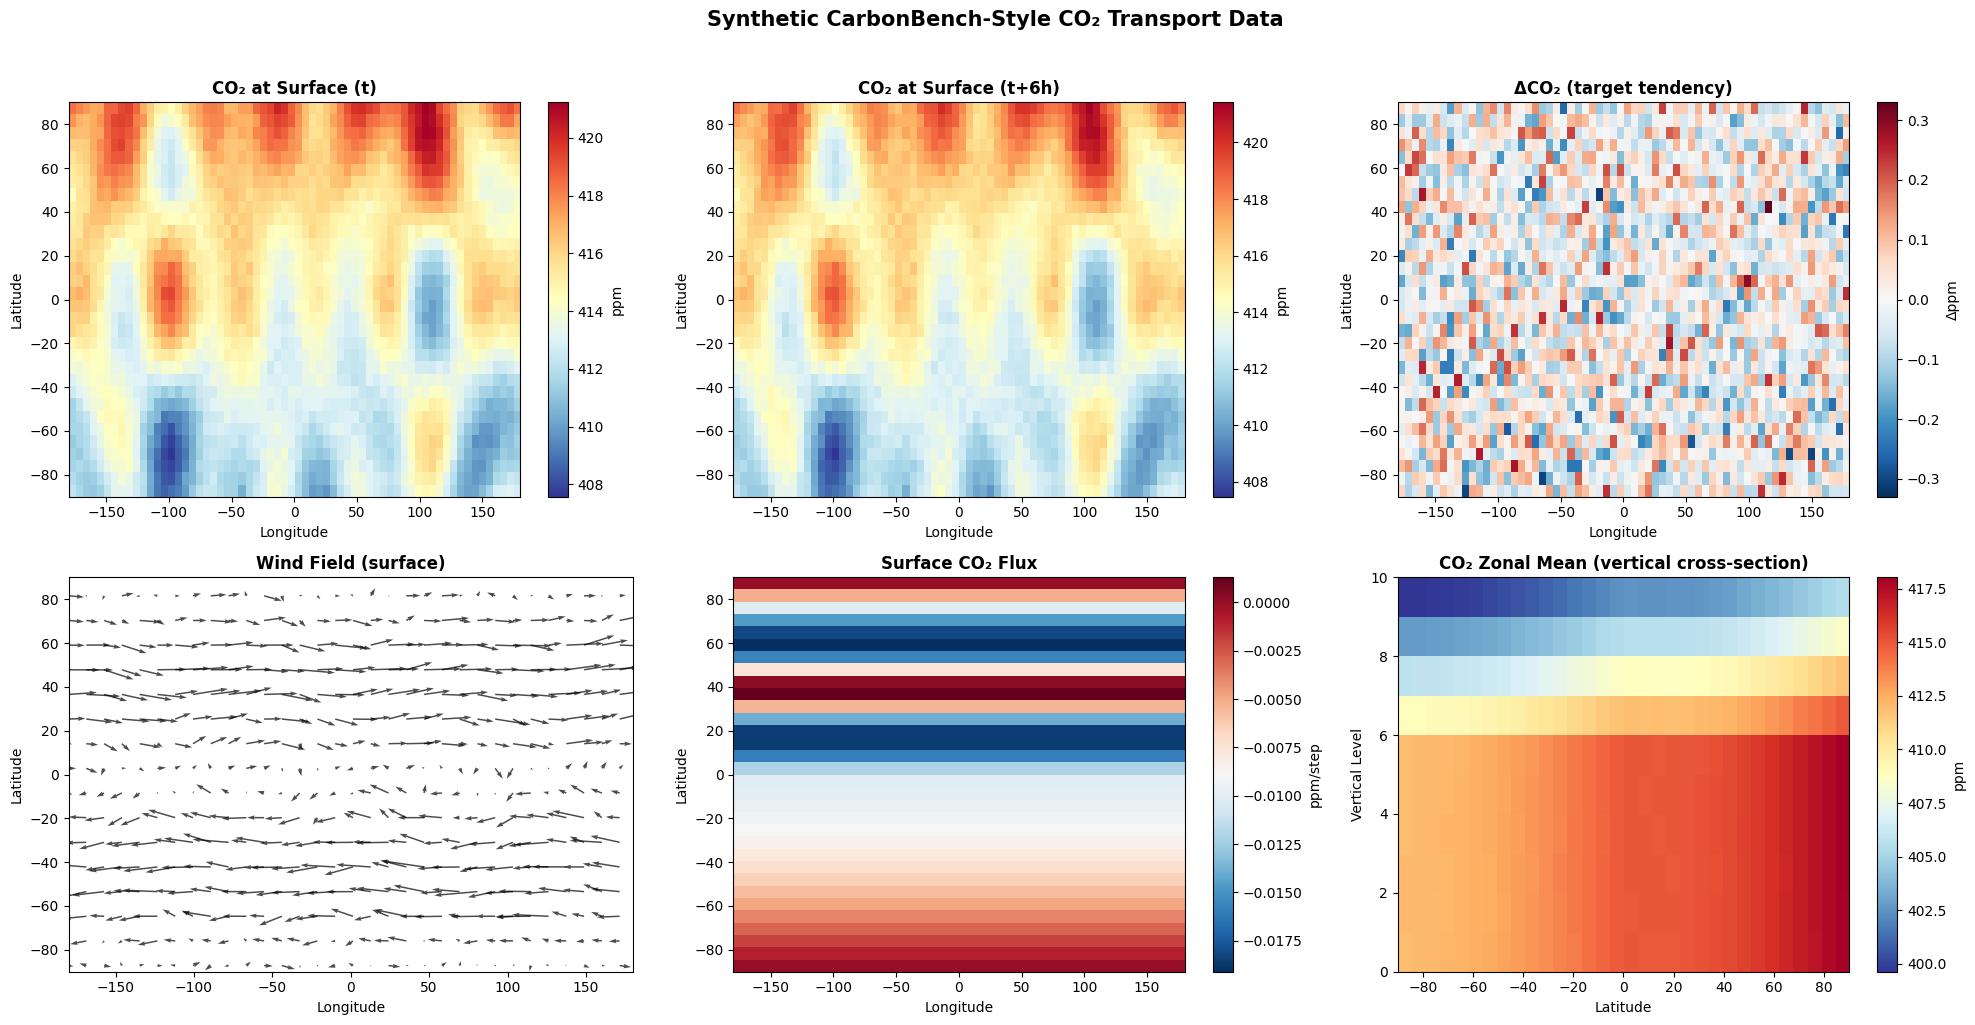

In [8]:
co2, co2_next, winds, sflux = train_ds[0]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# CO2 at surface level
im0 = axes[0,0].imshow(co2[:,:,0].numpy(), cmap='RdYlBu_r', origin='lower',
                         extent=[-180,180,-90,90], aspect='auto')
axes[0,0].set_title('CO₂ at Surface (t)', fontweight='bold')
plt.colorbar(im0, ax=axes[0,0], label='ppm')

# CO2 at t+dt
im1 = axes[0,1].imshow(co2_next[:,:,0].numpy(), cmap='RdYlBu_r', origin='lower',
                         extent=[-180,180,-90,90], aspect='auto')
axes[0,1].set_title('CO₂ at Surface (t+6h)', fontweight='bold')
plt.colorbar(im1, ax=axes[0,1], label='ppm')

# Delta (what the network predicts)
delta = co2_next[:,:,0] - co2[:,:,0]
vabs = max(abs(delta.min()), abs(delta.max()))
im2 = axes[0,2].imshow(delta.numpy(), cmap='RdBu_r', origin='lower',
                         extent=[-180,180,-90,90], aspect='auto',
                         vmin=-vabs, vmax=vabs)
axes[0,2].set_title('ΔCO₂ (target tendency)', fontweight='bold')
plt.colorbar(im2, ax=axes[0,2], label='Δppm')

# Wind field
skip = 2
axes[1,0].quiver(grid_lon_2d[::skip, ::skip],
                  grid_lat_2d[::skip, ::skip],
                  winds[::skip,::skip,0,0].numpy(),
                  winds[::skip,::skip,0,1].numpy(),
                  scale=200, alpha=0.7)
axes[1,0].set_title('Wind Field (surface)', fontweight='bold')
axes[1,0].set_xlim(-180,180); axes[1,0].set_ylim(-90,90)

# Surface flux
im4 = axes[1,1].imshow(sflux.numpy(), cmap='RdBu_r', origin='lower',
                         extent=[-180,180,-90,90], aspect='auto')
axes[1,1].set_title('Surface CO₂ Flux', fontweight='bold')
plt.colorbar(im4, ax=axes[1,1], label='ppm/step')

# Vertical profile (zonal mean)
zonal_mean = co2.mean(dim=1).numpy()  # [lat, vert]
im5 = axes[1,2].imshow(zonal_mean.T, cmap='RdYlBu_r', origin='lower',
                         extent=[-90,90,0,N_VERT], aspect='auto')
axes[1,2].set_xlabel('Latitude'); axes[1,2].set_ylabel('Vertical Level')
axes[1,2].set_title('CO₂ Zonal Mean (vertical cross-section)', fontweight='bold')
plt.colorbar(im5, ax=axes[1,2], label='ppm')

for ax in axes.flat:
    if ax.get_xlabel() == '': ax.set_xlabel('Longitude')
    if ax.get_ylabel() == '': ax.set_ylabel('Latitude')

plt.suptitle('Synthetic CarbonBench-Style CO₂ Transport Data', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

<div style="background: #e8f5e9; border-left: 4px solid #4caf50; padding: 12px; border-radius: 4px;">
<b>✅ Checkpoint:</b> The CO₂ field shows realistic patterns: higher concentrations in the Northern Hemisphere (anthropogenic emissions), a seasonal biosphere signal, and synoptic-scale variability. The target tendency (ΔCO₂) is what the network will learn to predict — it encodes the combined effect of wind-driven advection and surface fluxes.
</div>

---
# 3. Part 2 — GraphCast-Style GNN Architecture

## 3.1 Message Passing Layer

The core computation in GraphCast is **message passing** on the icosahedral mesh. Each vertex aggregates information from its neighbors, analogous to a finite-difference stencil on the sphere.


Instead of using traditional calculus equations to move air and moisture, the model uses the following code to let each point on the globe (a node) "talk" to its neighbors on the icosahedral mesh.

Think of it as a three-step conversation happening simultaneously across the entire planet.

  **Step 1. The "Message"**
    
  The message function defines what neighbor $j$ has to say to node $i$.
    
  * **The Inputs:** It looks at the weather at the receiver ($x_i$), the weather at the sender ($x_j$), and the physical relationship between them (edge_attr, like the distance and direction between them).
    
  * **The Logic:** The edge_mlp (a mini neural network) processes this data to decide how much "influence" the sender has. For example: "I am a cold node to your West, and the wind is blowing East toward you, so I'm sending a 'cooling' message."
    
  
  **Step 2. The "Aggregation"**
    
  * After every neighbor has calculated its message, the node $i$ collects them all. Aggregation (taking the mean - super().__init__(aggr='mean')) blends these messages into a single summary. If three neighbors say "it's getting warmer" and one says "it's getting colder," the average message will reflect a moderate warming trend.
  
  **Step 3. The "Update"**
  
  The forward function takes that summarized message and updates the weather state.
  
  * **Integration:** The node takes its current state (x) and the combined message from all neighbors (out) and runs them through node_mlp.
  
  * **Residual Connection:** The x + out part tells the model: "Keep what you already know about the weather, and just add the small changes (the delta) calculated from this round of messaging."

In [9]:
class MeshMessagePassing(MessagePassing):
    """
    Message passing on the icosahedral mesh.

    For each edge (i→j), compute a message from the sender and receiver
    features, aggregate over neighbors, then update the node.
    This is the "processor" component of GraphCast.

    Analogous to local stencils in a finite-difference solver on the sphere.
    """
    def __init__(self, hidden_dim, edge_dim=3):
        super().__init__(aggr='mean')  # Mean aggregation
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim + edge_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.node_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, x, edge_index, edge_attr):
        # x: [N_nodes, hidden_dim]
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        out = self.node_mlp(torch.cat([x, out], dim=-1))
        return self.norm(x + out)  # Residual connection

    def message(self, x_i, x_j, edge_attr):
        # x_i: receiver, x_j: sender, edge_attr: edge features
        return self.edge_mlp(torch.cat([x_i, x_j, edge_attr], dim=-1))

## 3.2 Encode–Process–Decode Architecture

In [21]:
class GraphCastCO2(nn.Module):
    """
    GraphCast-style Encode-Process-Decode GNN for CO2 transport.

    Following Benson et al. (2025) and Lam et al. (2023):
      Encoder:   lat-lon grid → icosahedral mesh (learned regridding + projection)
      Processor: Message passing on icosahedral mesh (N rounds)
      Decoder:   icosahedral mesh → lat-lon grid (learned regridding + projection)

    Physics-based adjustments (Benson et al., 2025):
      - CentFlux: CO2 is centered (global mean subtracted) before input,
                  and surface fluxes are added to the lowest vertical layer
      - Predicts TENDENCY (delta), not absolute field

    Reference: github.com/vitusbenson/neural_transport
    """
    def __init__(self, n_input_channels, n_output_channels, hidden_dim=128,
                 n_processor_steps=4, grid_to_ico_idx=None, ico_to_grid_idx=None,
                 ico_edge_index=None, ico_verts=None, n_grid=None):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_processor_steps = n_processor_steps

        # Store mesh topology as buffers (not parameters)
        self.register_buffer('grid_to_ico', torch.from_numpy(grid_to_ico_idx).long())
        self.register_buffer('ico_to_grid', torch.from_numpy(ico_to_grid_idx).long())
        self.register_buffer('ico_edges', torch.from_numpy(ico_edge_index).long())
        self.n_ico = len(ico_verts)
        self.n_grid = n_grid

        # Precompute edge attributes (relative position on unit sphere)
        src_pos = ico_verts[ico_edge_index[0]]
        dst_pos = ico_verts[ico_edge_index[1]]
        edge_attr = dst_pos - src_pos  # [n_edges, 3]
        self.register_buffer('edge_attr', torch.from_numpy(edge_attr).float())

        # ═══ Encoder: Grid → Mesh + Project to latent space ═══
        self.grid_encoder = nn.Sequential(
            nn.Linear(n_input_channels, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        # ═══ Processor: Message passing on icosahedral mesh ═══
        self.processors = nn.ModuleList([
            MeshMessagePassing(hidden_dim, edge_dim=3)
            for _ in range(n_processor_steps)
        ])

        # ═══ Decoder: Mesh → Grid + Project to output space ═══
        self.grid_decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, n_output_channels),
        )

    def forward(self, grid_features):
        """
        grid_features: [B, N_grid, C_in]  (flattened lat-lon grid)
        returns:       [B, N_grid, C_out] (predicted tendency)
        """
        B = grid_features.shape[0]
        outputs = []

        for b in range(B):
            x_grid = grid_features[b]  # [N_grid, C_in]

            # ═══ ENCODE: grid → mesh ═══
            # Project grid features to latent space
            x_grid_latent = self.grid_encoder(x_grid)  # [N_grid, hidden]

            # Map to icosahedral mesh (aggregate from nearest grid points)
            x_mesh = torch.zeros(self.n_ico, self.hidden_dim, device=x_grid.device)
            x_mesh.index_add_(0, self.grid_to_ico, x_grid_latent)
            # Average by counting how many grid points map to each ico vertex
            counts = torch.zeros(self.n_ico, device=x_grid.device)
            counts.index_add_(0, self.grid_to_ico, torch.ones(self.n_grid, device=x_grid.device))
            counts = counts.clamp(min=1).unsqueeze(-1)
            x_mesh = x_mesh / counts

            # ═══ PROCESS: message passing on icosahedral mesh ═══
            for processor in self.processors:
                x_mesh = processor(x_mesh, self.ico_edges, self.edge_attr)

            # ═══ DECODE: mesh → grid ═══
            # Corrected: Use grid_to_ico to map mesh features back to grid points
            x_grid_out = x_mesh[self.grid_to_ico]  # [N_grid, hidden]
            delta = self.grid_decoder(x_grid_out)   # [N_grid, C_out]
            outputs.append(delta)

        return torch.stack(outputs)  # [B, N_grid, C_out]


# ═══ Build model ═══
# Input channels: CO2 (N_VERT levels) + winds (N_VERT * 2) + surface flux (1)
n_in = N_VERT + N_VERT * 2 + 1  # CO2 + u,v winds + flux = 31 channels
n_out = N_VERT  # Predict CO2 tendency at each vertical level

model = GraphCastCO2(
    n_input_channels=n_in,
    n_output_channels=n_out,
    hidden_dim=128,
    n_processor_steps=4,
    grid_to_ico_idx=grid_to_ico,
    ico_to_grid_idx=ico_to_grid,
    ico_edge_index=ico_edges,
    ico_verts=ico_verts,
    n_grid=N_LAT * N_LON,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f'GraphCast CO2 Transport Model')
print(f'  Input:  {n_in} channels (CO2×{N_VERT} + wind×{N_VERT*2} + flux×1)')
print(f'  Output: {n_out} channels (ΔCO2×{N_VERT})')
print(f'  Hidden: {model.hidden_dim}')
print(f'  Processor steps: {model.n_processor_steps} message passing rounds')
print(f'  Ico mesh: {model.n_ico} vertices, {ico_edges.shape[1]} edges')
print(f'  Parameters: {n_params:,}')

GraphCast CO2 Transport Model
  Input:  31 channels (CO2×10 + wind×20 + flux×1)
  Output: 10 channels (ΔCO2×10)
  Hidden: 128
  Processor steps: 4 message passing rounds
  Ico mesh: 642 vertices, 3840 edges
  Parameters: 436,234


<div style="background: #e3f2fd; border-left: 4px solid #1e88e5; padding: 12px; border-radius: 4px;">
<b>🏗️ Architecture Summary (GraphCast for CO₂):</b><br>
<b>Input:</b> Flattened lat–lon grid features: CO₂ (10 levels) + winds (10 levels × 2) + surface flux (1) = 31 channels<br>
<b>Encoder:</b> MLP projects grid features to 128-dim latent space → scatter to icosahedral mesh<br>
<b>Processor:</b> 4 rounds of message passing on the icosahedral mesh with residual connections<br>
<b>Decoder:</b> Gather from icosahedral mesh → MLP projects back to ΔCO₂ at 10 vertical levels<br>
<b>Output:</b> Tendency field (ΔCO₂) — the actual CO₂ at t+dt is: CO₂(t) + ΔCO₂
</div>

---
# 4. Part 3 — Training with CentFlux and SpecLoss

## 4.1 CentFlux Preprocessing

Following Benson et al. (2025), we **center** the CO₂ field by subtracting the global spatial mean before feeding it to the network. This removes the secular rise (~2.5 ppm/year) from the input distribution. We also explicitly **add surface fluxes** to the lowest vertical layer.

In [11]:
def prepare_inputs(co2, winds, surface_flux):
    """
    CentFlux preprocessing (Benson et al., 2025):
    1. Center CO2 by subtracting spatial mean at each level
    2. Flatten spatial dims and stack all channels
    """
    # co2: [B, lat, lon, vert]
    # winds: [B, lat, lon, vert, 2]
    # surface_flux: [B, lat, lon]
    B, nlat, nlon, nvert = co2.shape

    # Center CO2 (remove global mean per level)
    co2_mean = co2.mean(dim=(1, 2), keepdim=True)  # [B, 1, 1, vert]
    co2_centered = co2 - co2_mean

    # Flatten spatial dims → [B, lat*lon, ...]
    co2_flat = co2_centered.reshape(B, nlat*nlon, nvert)
    wind_flat = winds.reshape(B, nlat*nlon, nvert*2)
    flux_flat = surface_flux.reshape(B, nlat*nlon, 1)

    # Stack all channels: [B, N_grid, n_in]
    x = torch.cat([co2_flat, wind_flat, flux_flat], dim=-1)
    return x, co2_mean


def compute_target(co2, co2_next, co2_mean):
    """Compute centered tendency: target = (co2_next - co2_mean) - (co2 - co2_mean) = co2_next - co2"""
    B, nlat, nlon, nvert = co2.shape
    delta = co2_next - co2  # Tendency in original space
    return delta.reshape(B, nlat*nlon, nvert)

## 4.2 Loss Functions

In [12]:
def latitude_weighted_mse(pred, target, lats, n_lat, n_lon):
    """
    MSE weighted by cos(latitude) to account for grid cell area variation.
    Standard in CarbonBench evaluation.
    """
    lat_weights = np.cos(np.radians(lats))
    lat_weights /= lat_weights.mean()
    # Expand to grid: [N_grid]
    w = np.repeat(lat_weights, n_lon)
    w = torch.from_numpy(w).float().to(pred.device)
    # Weighted MSE: [B, N_grid, C]
    mse = ((pred - target)**2 * w[None, :, None]).mean()
    return mse


def spectral_loss(pred, target, n_lat, n_lon):
    """
    SpecLoss (Benson et al., 2025): Penalize deviations in the spatial
    power spectrum. Uses 2D FFT as a proxy for spherical harmonics.
    Prevents loss of small-scale variability.
    """
    # Reshape to [B, lat, lon, C]
    B, N, C = pred.shape
    pred_2d = pred.reshape(B, n_lat, n_lon, C)
    tgt_2d  = target.reshape(B, n_lat, n_lon, C)
    # 2D FFT power spectrum
    pred_spec = torch.fft.rfft2(pred_2d, dim=(1, 2)).abs()
    tgt_spec  = torch.fft.rfft2(tgt_2d, dim=(1, 2)).abs()
    return F.mse_loss(pred_spec, tgt_spec)


def mass_fixer(co2_pred, co2_input, surface_flux, dt=1.0):
    """
    Post-hoc mass conservation (Benson et al., 2025).
    Adjust predicted CO2 so that total mass change equals
    the integrated surface flux.
    """
    # Expected mass change from fluxes
    expected_delta_mass = surface_flux.sum(dim=(1, 2)) * dt  # [B]
    # Actual mass change
    actual_delta_mass = (co2_pred - co2_input).sum(dim=(1, 2, 3))  # [B]
    # Correction: spread error uniformly
    n_cells = co2_pred.shape[1] * co2_pred.shape[2] * co2_pred.shape[3]
    correction = ((expected_delta_mass - actual_delta_mass) / n_cells)
    return co2_pred + correction[:, None, None, None]

## 4.3 Training Loop

In [13]:
def collate_fn(batch):
    co2     = torch.stack([b[0] for b in batch])
    co2_nxt = torch.stack([b[1] for b in batch])
    winds   = torch.stack([b[2] for b in batch])
    flux    = torch.stack([b[3] for b in batch])
    return co2, co2_nxt, winds, flux

EPOCHS = 10
BATCH_SIZE = 8
LR = 5e-4
SPEC_WEIGHT = 0.1  # Weight for spectral loss

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

lats_arr = np.linspace(-87.19, 87.19, N_LAT)
print(f'Training: {len(train_ds)} samples, {EPOCHS} epochs, batch={BATCH_SIZE}')
print(f'Loss = LatWeightedMSE + {SPEC_WEIGHT} × SpecLoss')


Training: 1500 samples, 10 epochs, batch=8
Loss = LatWeightedMSE + 0.1 × SpecLoss


In [14]:
history = {'loss': [], 'val_rmse': []}
best_val = float('inf')

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for co2, co2_nxt, winds, flux in tqdm(train_loader,
                                           desc=f'Ep {epoch}/{EPOCHS}', leave=False):
        co2, co2_nxt = co2.to(DEVICE), co2_nxt.to(DEVICE)
        winds, flux = winds.to(DEVICE), flux.to(DEVICE)

        # CentFlux preprocessing
        x, co2_mean = prepare_inputs(co2, winds, flux)
        target = compute_target(co2, co2_nxt, co2_mean)

        optimizer.zero_grad()
        pred_delta = model(x)  # [B, N_grid, N_VERT]

        # Combined loss: spatial MSE + spectral
        loss_mse  = latitude_weighted_mse(pred_delta, target, lats_arr, N_LAT, N_LON)
        loss_spec = spectral_loss(pred_delta, target, N_LAT, N_LON)
        loss = loss_mse + SPEC_WEIGHT * loss_spec

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running += loss.item() * co2.size(0)

    train_loss = running / len(train_loader.dataset)

    # Validation RMSE
    model.eval()
    val_se = 0.0; val_n = 0
    with torch.no_grad():
        for co2, co2_nxt, winds, flux in val_loader:
            co2, co2_nxt = co2.to(DEVICE), co2_nxt.to(DEVICE)
            winds, flux = winds.to(DEVICE), flux.to(DEVICE)
            x, co2_mean = prepare_inputs(co2, winds, flux)
            target = compute_target(co2, co2_nxt, co2_mean)

            pred = model(x)
            val_se += ((pred - target)**2).sum().item()
            val_n += target.numel()
    val_rmse = np.sqrt(val_se / val_n)

    scheduler.step(val_rmse) # Pass val_rmse to the scheduler

    history['loss'].append(train_loss)
    history['val_rmse'].append(val_rmse)

    star = ''
    if val_rmse < best_val:
        best_val = val_rmse
        torch.save(model.state_dict(), 'best_graphcast_co2.pth')
        star = ' ★'

    if epoch % 5 == 0 or epoch == 1 or star:
        print(f'Ep {epoch:3d} │ Loss: {train_loss:.6f} │ Val RMSE: {val_rmse:.6f} ppm{star}')

print(f'\n✅ Best validation RMSE: {best_val:.6f} ppm')

Ep 1/10:   0%|          | 0/188 [00:00<?, ?it/s]

Ep   1 │ Loss: 1.189472 │ Val RMSE: 0.124821 ppm ★


Ep 2/10:   0%|          | 0/188 [00:00<?, ?it/s]

Ep   2 │ Loss: 0.879192 │ Val RMSE: 0.123390 ppm ★


Ep 3/10:   0%|          | 0/188 [00:00<?, ?it/s]

...

Ep   7 │ Loss: 0.847844 │ Val RMSE: 0.121898 ppm ★


Ep 8/10:   0%|          | 0/188 [00:00<?, ?it/s]

Ep 9/10:   0%|          | 0/188 [00:00<?, ?it/s]

Ep 10/10:   0%|          | 0/188 [00:00<?, ?it/s]

Ep  10 │ Loss: 0.837550 │ Val RMSE: 0.121178 ppm ★

✅ Best validation RMSE: 0.121178 ppm


### Training Curves

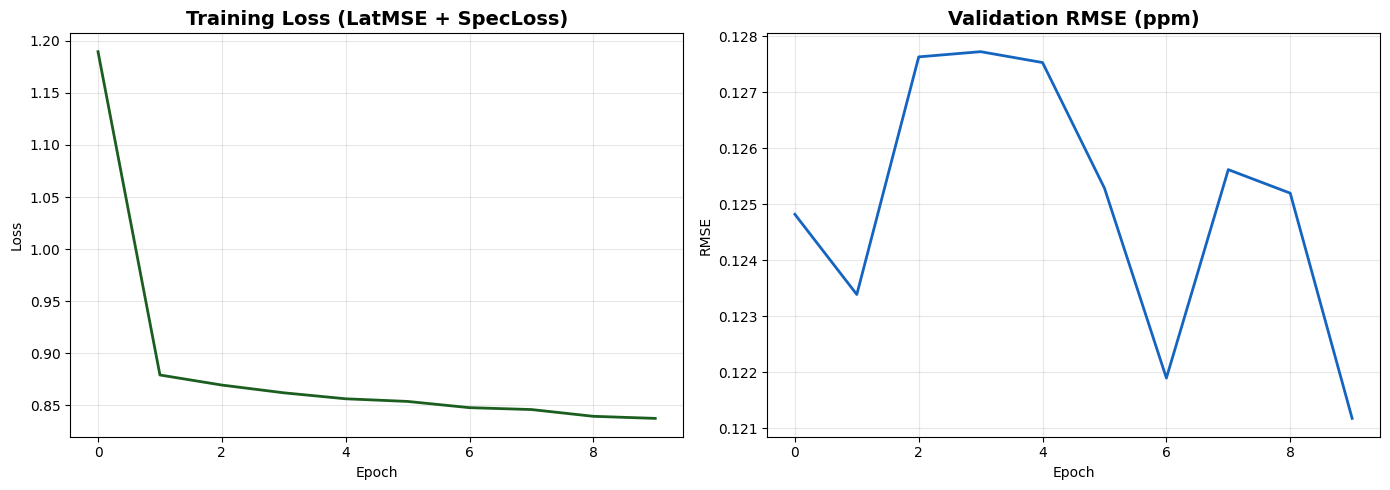

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history['loss'], color='#1b5e20', linewidth=2)
ax1.set_title('Training Loss (LatMSE + SpecLoss)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(alpha=0.3)

ax2.plot(history['val_rmse'], color='#1565C0', linewidth=2)
ax2.set_title('Validation RMSE (ppm)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('RMSE'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
# 5. Part 4 — Evaluation & Multi-Step Rollouts

## 5.1 Single-Step Prediction

In [16]:
model.load_state_dict(torch.load('best_graphcast_co2.pth', map_location=DEVICE))
model.eval()

# Get a test sample
co2, co2_nxt, winds, flux = test_ds[0]
co2_b = co2.unsqueeze(0).to(DEVICE)
winds_b = winds.unsqueeze(0).to(DEVICE)
flux_b = flux.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    x, co2_mean = prepare_inputs(co2_b, winds_b, flux_b)
    pred_delta = model(x)

# Reconstruct full CO2 field
delta_pred = pred_delta[0].cpu().reshape(N_LAT, N_LON, N_VERT)
co2_pred = co2 + delta_pred

# Apply mass fixer
co2_pred_fixed = mass_fixer(
    co2_pred.unsqueeze(0), co2.unsqueeze(0), flux.unsqueeze(0)
).squeeze(0)

# Metrics
target_delta = (co2_nxt - co2).numpy()
pred_delta_np = delta_pred.numpy()
rmse = np.sqrt(np.mean((pred_delta_np - target_delta)**2))
r2 = 1 - np.sum((pred_delta_np - target_delta)**2) / np.sum((target_delta - target_delta.mean())**2)
print(f'Single-step RMSE:  {rmse:.6f} ppm')
print(f'Single-step R²:    {r2:.4f}')

# Mass conservation check
mass_before = co2.sum().item()
mass_after_raw = co2_pred.sum().item()
mass_after_fixed = co2_pred_fixed.sum().item()
mass_expected = mass_before + flux.sum().item()
print(f'\nMass conservation:')
print(f'  Before:           {mass_before:.2f}')
print(f'  Expected (w/flux): {mass_expected:.2f}')
print(f'  After (raw):       {mass_after_raw:.2f} (error: {abs(mass_after_raw-mass_expected):.4f})')
print(f'  After (fixed):     {mass_after_fixed:.2f} (error: {abs(mass_after_fixed-mass_expected):.4f})')

Single-step RMSE:  0.120047 ppm
Single-step R²:    -0.4257

Mass conservation:
  Before:           8433162.00
  Expected (w/flux): 8433154.75
  After (raw):       8433174.00 (error: 19.2459)
  After (fixed):     8433154.00 (error: 0.7541)


## 5.2 Visualize Predictions

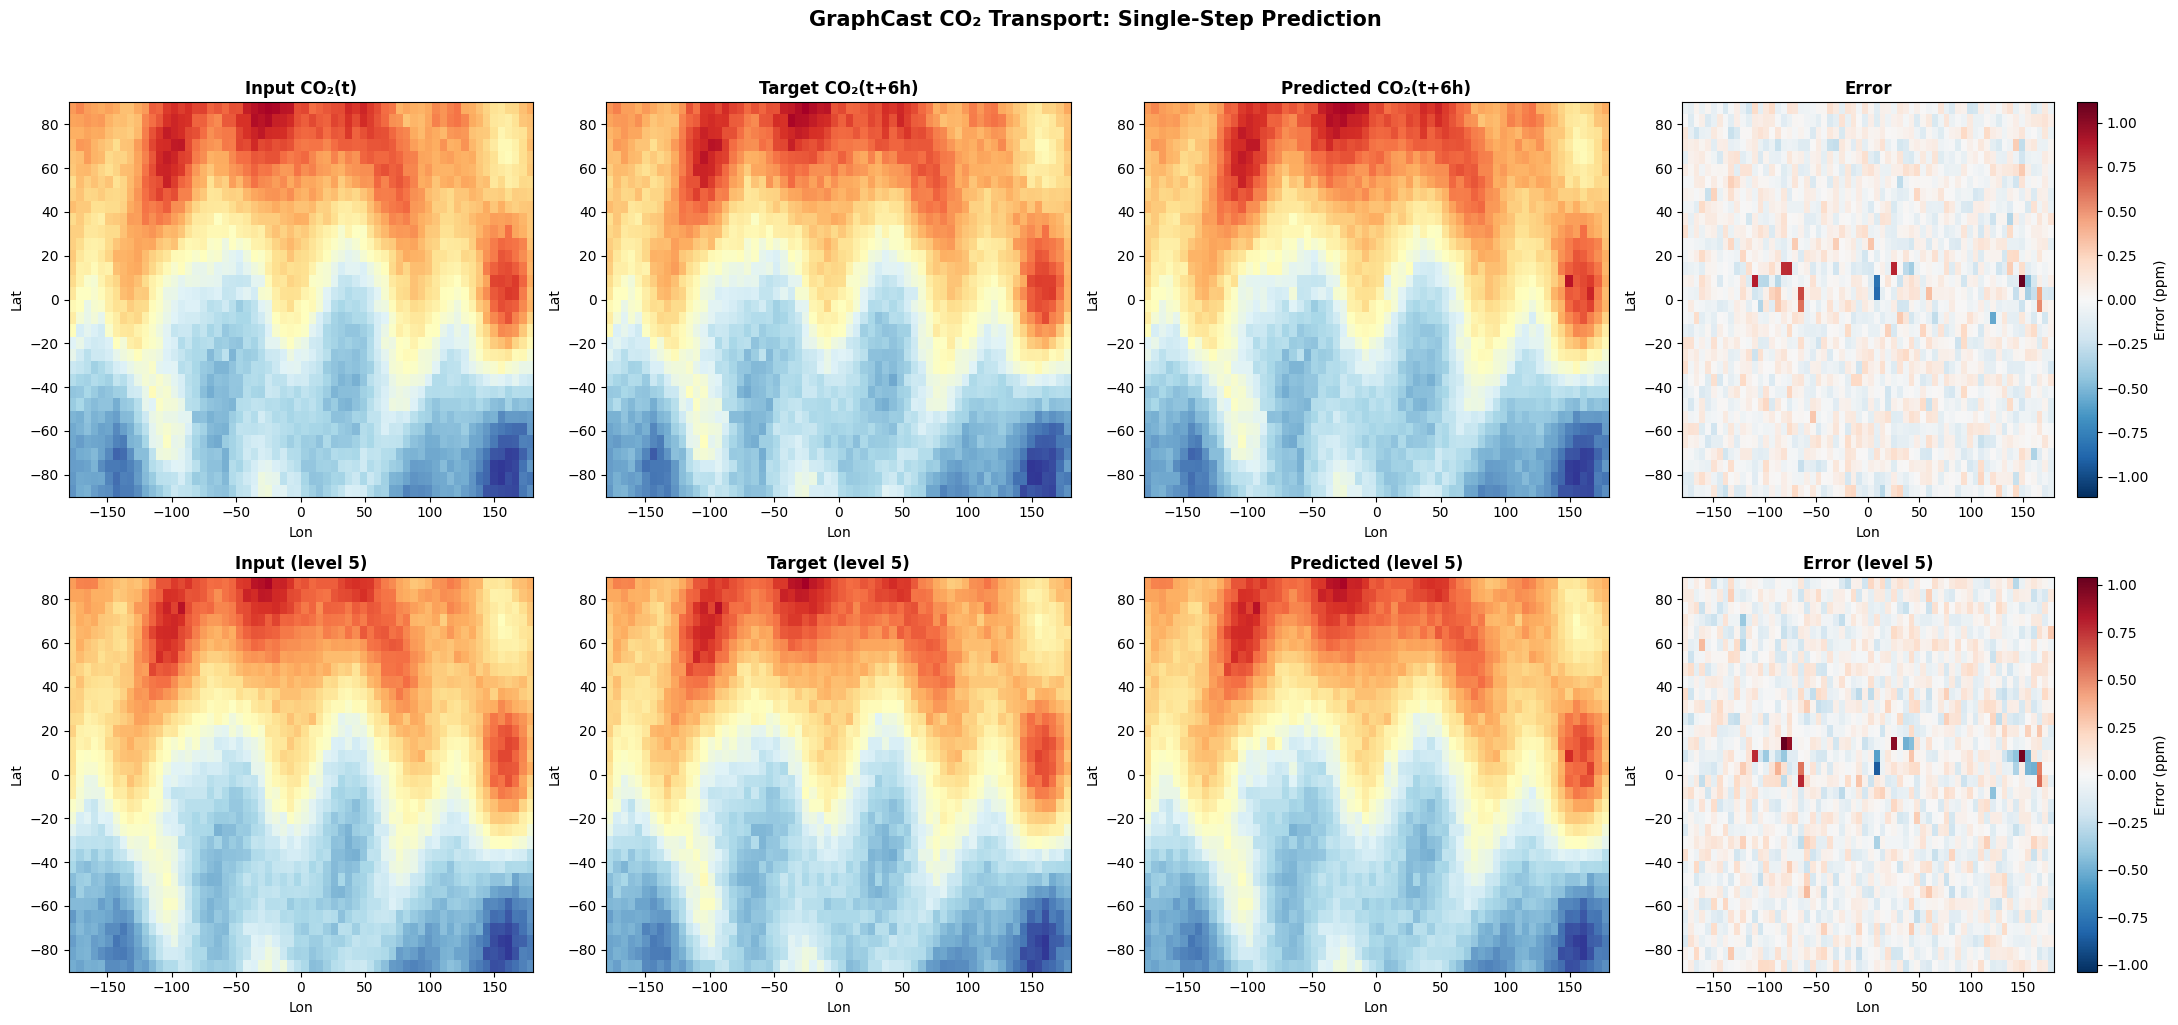

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

level = 0  # Surface level
titles_top = ['Input CO₂(t)', 'Target CO₂(t+6h)', 'Predicted CO₂(t+6h)', 'Error']
titles_bot = ['Input (level 5)', 'Target (level 5)', 'Predicted (level 5)', 'Error (level 5)']

for row, lev, titles in [(0, 0, titles_top), (1, N_VERT//2, titles_bot)]:
    vmin = min(co2[:,:,lev].min(), co2_nxt[:,:,lev].min())
    vmax = max(co2[:,:,lev].max(), co2_nxt[:,:,lev].max())

    axes[row,0].imshow(co2[:,:,lev].numpy(), cmap='RdYlBu_r', origin='lower',
                       extent=[-180,180,-90,90], aspect='auto', vmin=vmin, vmax=vmax)
    axes[row,1].imshow(co2_nxt[:,:,lev].numpy(), cmap='RdYlBu_r', origin='lower',
                       extent=[-180,180,-90,90], aspect='auto', vmin=vmin, vmax=vmax)
    axes[row,2].imshow(co2_pred_fixed[:,:,lev].detach().numpy(), cmap='RdYlBu_r',
                       origin='lower', extent=[-180,180,-90,90], aspect='auto',
                       vmin=vmin, vmax=vmax)

    err = co2_pred_fixed[:,:,lev].detach().numpy() - co2_nxt[:,:,lev].numpy()
    eabs = max(abs(err.min()), abs(err.max()), 0.01)
    im = axes[row,3].imshow(err, cmap='RdBu_r', origin='lower',
                            extent=[-180,180,-90,90], aspect='auto',
                            vmin=-eabs, vmax=eabs)
    plt.colorbar(im, ax=axes[row,3], label='Error (ppm)')

    for j, t in enumerate(titles):
        axes[row, j].set_title(t, fontweight='bold')
        axes[row, j].set_xlabel('Lon'); axes[row, j].set_ylabel('Lat')

plt.suptitle('GraphCast CO₂ Transport: Single-Step Prediction',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 5.3 Multi-Step Rollout

A key challenge identified by Benson et al. (2025) is **stability over long rollouts**. In their experiments, the best models maintained stable predictions for >3 years, while GraphCast became unstable after ~178 days. We test our model's stability over multiple time steps.

Rollout: 20 steps (120h = 5.0 days)
  Mean step RMSE: 0.039847 ppm
  Mass drift: 144.0000 ppm total


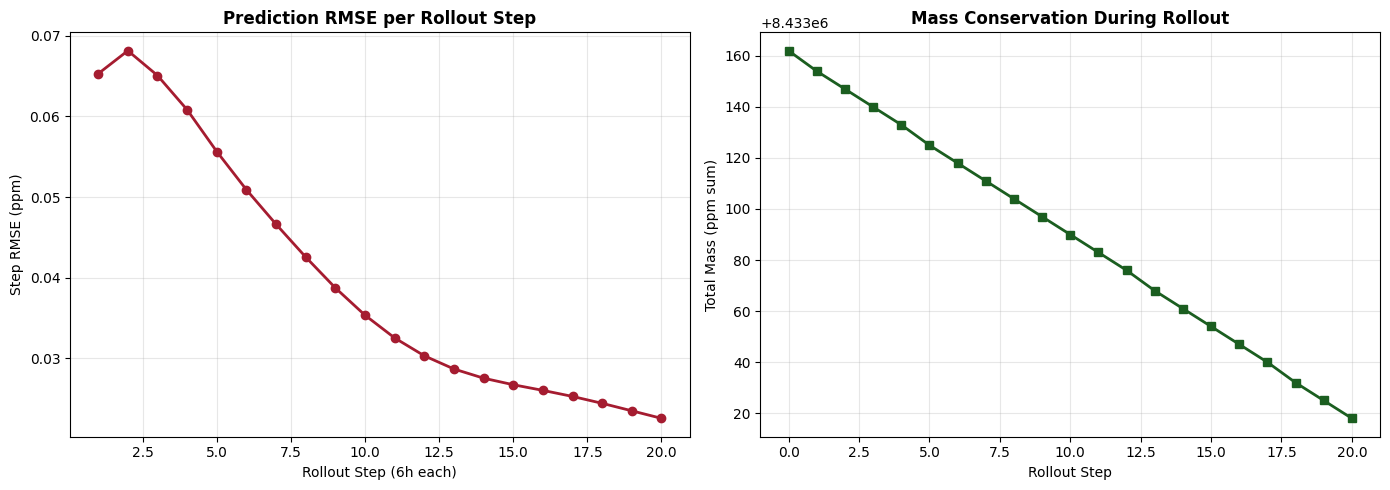

In [18]:
N_STEPS = 20  # 20 × 6h = 5 days
model.eval()

co2_current = co2.unsqueeze(0).to(DEVICE)
rollout_rmse = []
rollout_mass = [co2_current.sum().item()]

# Use same wind/flux for simplicity (in practice these change each step)
winds_b = winds.unsqueeze(0).to(DEVICE)
flux_b = flux.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    for step in range(N_STEPS):
        x, co2_mean = prepare_inputs(co2_current, winds_b, flux_b)
        pred_delta = model(x)
        delta = pred_delta.reshape(1, N_LAT, N_LON, N_VERT)

        co2_current = co2_current + delta
        # Apply mass fixer
        co2_current = mass_fixer(co2_current, co2_current - delta, flux_b)

        rollout_mass.append(co2_current.sum().item())
        # RMSE vs. a simple linear extrapolation of the tendency
        rmse_step = torch.sqrt(((delta)**2).mean()).item()
        rollout_rmse.append(rmse_step)

print(f'Rollout: {N_STEPS} steps ({N_STEPS * 6}h = {N_STEPS * 6 / 24:.1f} days)')
print(f'  Mean step RMSE: {np.mean(rollout_rmse):.6f} ppm')
print(f'  Mass drift: {abs(rollout_mass[-1] - rollout_mass[0]):.4f} ppm total')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(range(1, N_STEPS+1), rollout_rmse, 'o-', color='#A51C30', linewidth=2)
ax1.set_xlabel('Rollout Step (6h each)'); ax1.set_ylabel('Step RMSE (ppm)')
ax1.set_title('Prediction RMSE per Rollout Step', fontweight='bold')
ax1.grid(alpha=0.3)

ax2.plot(range(N_STEPS+1), rollout_mass, 's-', color='#1b5e20', linewidth=2)
ax2.set_xlabel('Rollout Step'); ax2.set_ylabel('Total Mass (ppm sum)')
ax2.set_title('Mass Conservation During Rollout', fontweight='bold')
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
# 6. Part 5 — Experiments

## 6.1 Experiment A: U-Net Baseline Comparison

Benson et al. (2025) compared GraphCast against a U-Net (which operates on the regular lat–lon grid). The U-Net is analogous to a finite-difference solver on a regular mesh.

In [19]:
class UNetCO2(nn.Module):
    """
    Simple U-Net baseline for CO2 transport on regular lat-lon grid.
    Operates directly on 2D spatial fields (no icosahedral mesh).
    Analogous to finite differences on a regular grid (Benson et al., 2025).
    """
    def __init__(self, n_in, n_out, base_ch=64):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(n_in, base_ch, 3, padding=1),
                                   nn.ReLU(), nn.Conv2d(base_ch, base_ch, 3, padding=1), nn.ReLU())
        self.enc2 = nn.Sequential(nn.Conv2d(base_ch, base_ch*2, 3, padding=1),
                                   nn.ReLU(), nn.Conv2d(base_ch*2, base_ch*2, 3, padding=1), nn.ReLU())
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = nn.Sequential(nn.Conv2d(base_ch*2, base_ch*4, 3, padding=1),
                                        nn.ReLU(), nn.Conv2d(base_ch*4, base_ch*4, 3, padding=1), nn.ReLU())
        self.up1 = nn.ConvTranspose2d(base_ch*4, base_ch*2, 2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(base_ch*4, base_ch*2, 3, padding=1),
                                   nn.ReLU(), nn.Conv2d(base_ch*2, base_ch*2, 3, padding=1), nn.ReLU())
        self.up2 = nn.ConvTranspose2d(base_ch*2, base_ch, 2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(base_ch*2, base_ch, 3, padding=1),
                                   nn.ReLU(), nn.Conv2d(base_ch, base_ch, 3, padding=1), nn.ReLU())
        self.head = nn.Conv2d(base_ch, n_out, 1)

    def forward(self, x):
        # x: [B, C_in, H, W]
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b = self.bottleneck(self.pool(e2))
        d1 = self.dec1(torch.cat([self.up1(b), e2], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d1), e1], dim=1))
        return self.head(d2)  # [B, C_out, H, W]


unet = UNetCO2(n_in=n_in, n_out=n_out, base_ch=32)
unet_params = sum(p.numel() for p in unet.parameters())
print(f'U-Net baseline: {unet_params:,} parameters')
print(f'GraphCast GNN:  {n_params:,} parameters')
print()
print('→ Train the U-Net with the same loss functions and compare:')
print('  - Single-step RMSE / R²')
print('  - Rollout stability (does it diverge faster than GraphCast?)')
print('  - Polar artifacts (U-Net uses zero-padding → pole errors)')

U-Net baseline: 474,890 parameters
GraphCast GNN:  436,234 parameters

→ Train the U-Net with the same loss functions and compare:
  - Single-step RMSE / R²
  - Rollout stability (does it diverge faster than GraphCast?)
  - Polar artifacts (U-Net uses zero-padding → pole errors)


In [22]:
# history = {'loss': [], 'val_rmse': []}
# best_val = float('inf')

# model = unet

# for epoch in range(1, EPOCHS + 1):
#     model.train()
#     running = 0.0
#     for co2, co2_nxt, winds, flux in tqdm(train_loader,
#                                            desc=f'Ep {epoch}/{EPOCHS}', leave=False):
#         co2, co2_nxt = co2.to(DEVICE), co2_nxt.to(DEVICE)
#         winds, flux = winds.to(DEVICE), flux.to(DEVICE)

#         # CentFlux preprocessing
#         x, co2_mean = prepare_inputs(co2, winds, flux)
#         target = compute_target(co2, co2_nxt, co2_mean)

#         optimizer.zero_grad()
#         pred_delta = model(x)  # [B, N_grid, N_VERT]

#         # Combined loss: spatial MSE + spectral
#         loss_mse  = latitude_weighted_mse(pred_delta, target, lats_arr, N_LAT, N_LON)
#         loss_spec = spectral_loss(pred_delta, target, N_LAT, N_LON)
#         loss = loss_mse + SPEC_WEIGHT * loss_spec

#         loss.backward()
#         nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         optimizer.step()
#         running += loss.item() * co2.size(0)

#     train_loss = running / len(train_loader.dataset)

#     # Validation RMSE
#     model.eval()
#     val_se = 0.0; val_n = 0
#     with torch.no_grad():
#         for co2, co2_nxt, winds, flux in val_loader:
#             co2, co2_nxt = co2.to(DEVICE), co2_nxt.to(DEVICE)
#             winds, flux = winds.to(DEVICE), flux.to(DEVICE)
#             x, co2_mean = prepare_inputs(co2, winds, flux)
#             target = compute_target(co2, co2_nxt, co2_mean)

#             pred = model(x)
#             val_se += ((pred - target)**2).sum().item()
#             val_n += target.numel()
#     val_rmse = np.sqrt(val_se / val_n)

#     scheduler.step(val_rmse) # Pass val_rmse to the scheduler

#     history['loss'].append(train_loss)
#     history['val_rmse'].append(val_rmse)

#     star = ''
#     if val_rmse < best_val:
#         best_val = val_rmse
#         torch.save(model.state_dict(), 'best_graphcast_co2.pth')
#         star = ' ★'

#     if epoch % 5 == 0 or epoch == 1 or star:
#         print(f'Ep {epoch:3d} │ Loss: {train_loss:.6f} │ Val RMSE: {val_rmse:.6f} ppm{star}')

# print(f'\n✅ Best validation RMSE: {best_val:.6f} ppm')

In [23]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# ax1.plot(history['loss'], color='#1b5e20', linewidth=2)
# ax1.set_title('Training Loss (LatMSE + SpecLoss)', fontsize=14, fontweight='bold')
# ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(alpha=0.3)

# ax2.plot(history['val_rmse'], color='#1565C0', linewidth=2)
# ax2.set_title('Validation RMSE (ppm)', fontsize=14, fontweight='bold')
# ax2.set_xlabel('Epoch'); ax2.set_ylabel('RMSE'); ax2.grid(alpha=0.3)
# plt.tight_layout(); plt.show()

## 6.2 Experiment B: Ablation of Physics-Based Tricks

Benson et al. (2025) showed that **CentFlux is essential** for stable rollouts, and **SpecLoss additionally enhances** performance. Test by removing each component:

```python
# Ablation 1: No CentFlux (feed raw CO2 without centering)
# → Expect: model struggles with distribution shift from rising CO2

# Ablation 2: No SpecLoss (train with MSE only)
# → Expect: predictions become overly smooth, losing small-scale structure

# Ablation 3: No mass fixer
# → Expect: total CO2 mass drifts over multi-step rollouts
```

## 6.3 Experiment C: Number of Message Passing Steps

```python
# How many processing rounds does GraphCast need?
for n_steps in [1, 2, 4, 8, 16]:
    model = GraphCastCO2(..., n_processor_steps=n_steps)
    # Train and compare — more steps = larger receptive field on the mesh
    # = longer-range transport captured per time step
```

## 6.4 Experiment D: Using Real CarbonBench Data

To use the full CarbonBench dataset, follow the instructions at [github.com/vitusbenson/carbonbench](https://github.com/vitusbenson/carbonbench):

```python
# Install NeuralTransport
!pip install neural-transport

# Download CarbonTracker data and preprocess to CarbonBench format
# See: https://github.com/vitusbenson/carbonbench/tree/main/data

# The data provides:
#   - 3D CO2 fields from TM5 transport model (25 vertical levels, 64×128 grid)
#   - ERA5 wind forcing at 3h resolution
#   - Surface fluxes (biosphere, ocean, fossil, fire)
#   - ObsPack station observations for validation

# Train/val/test splits follow CarbonBench convention
```

In [25]:
# B experiment no centflux preprocessing

history = {'loss': [], 'val_rmse': []}
best_val = float('inf')

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for co2, co2_nxt, winds, flux in tqdm(train_loader,
                                           desc=f'Ep {epoch}/{EPOCHS}', leave=False):
        co2, co2_nxt = co2.to(DEVICE), co2_nxt.to(DEVICE)
        winds, flux = winds.to(DEVICE), flux.to(DEVICE)

        # CentFlux preprocessing
        x, co2_mean = prepare_inputs(co2, winds, flux)
        target = compute_target(co2, co2_nxt, 0)

        optimizer.zero_grad()
        pred_delta = model(x)  # [B, N_grid, N_VERT]

        # Combined loss: spatial MSE + spectral
        loss_mse  = latitude_weighted_mse(pred_delta, target, lats_arr, N_LAT, N_LON)
        loss_spec = spectral_loss(pred_delta, target, N_LAT, N_LON)
        loss = loss_mse + SPEC_WEIGHT * loss_spec

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running += loss.item() * co2.size(0)

    train_loss = running / len(train_loader.dataset)

    # Validation RMSE
    model.eval()
    val_se = 0.0; val_n = 0
    with torch.no_grad():
        for co2, co2_nxt, winds, flux in val_loader:
            co2, co2_nxt = co2.to(DEVICE), co2_nxt.to(DEVICE)
            winds, flux = winds.to(DEVICE), flux.to(DEVICE)
            x, co2_mean = prepare_inputs(co2, winds, flux)
            target = compute_target(co2, co2_nxt, 0)

            pred = model(x)
            val_se += ((pred - target)**2).sum().item()
            val_n += target.numel()
    val_rmse = np.sqrt(val_se / val_n)

    scheduler.step(val_rmse) # Pass val_rmse to the scheduler

    history['loss'].append(train_loss)
    history['val_rmse'].append(val_rmse)

    star = ''
    if val_rmse < best_val:
        best_val = val_rmse
        torch.save(model.state_dict(), 'best_graphcast_co2.pth')
        star = ' ★'

    if epoch % 5 == 0 or epoch == 1 or star:
        print(f'Ep {epoch:3d} │ Loss: {train_loss:.6f} │ Val RMSE: {val_rmse:.6f} ppm{star}')

print(f'\n✅ Best validation RMSE: {best_val:.6f} ppm')

Ep 1/10:   0%|          | 0/188 [00:00<?, ?it/s]

Ep   1 │ Loss: 9.575975 │ Val RMSE: 0.185977 ppm ★


Ep 2/10:   0%|          | 0/188 [00:00<?, ?it/s]

KeyboardInterrupt: 

---
# 7. Discussion Questions

**Q1.** Benson et al. (2025) found that the **CentFlux** trick (centering CO₂ by subtracting the global mean) is essential for stable rollouts. Why? Consider what happens when atmospheric CO₂ rises by ~2.5 ppm/year — how does this create distribution shift for the neural network, and how does centering solve it?

**Q2.** The paper reports that GraphCast becomes unstable after ~178 days of autoregressive rollout, while SwinTransformer remains stable for >3 years. What properties of the SwinTransformer architecture might provide better long-term stability? Consider the role of attention vs. local message passing.

**Q3.** Why is **mass conservation** a hard physical constraint for CO₂ transport that doesn't apply (as strictly) to weather prediction? The mass fixer rescales the output — what are the tradeoffs of this post-hoc correction vs. building conservation into the architecture?

**Q4.** The **SpecLoss** (spectral power spectrum loss) prevents the model from losing small-scale variability. Why does MSE loss alone tend to produce overly smooth predictions? Draw an analogy to the blurriness problem in image generation with L2 loss.

*Write your answers below:*

**Q1:** *(Your answer)*

**Q2:** *(Your answer)*

**Q3:** *(Your answer)*

**Q4:** *(Your answer)*

---
# 8. References & Submission

### Software & Data

| Resource | Description |
|---|---|
| [NeuralTransport](https://github.com/vitusbenson/neural_transport) | Python library for neural network emulators of atmospheric transport (MIT License) |
| [CarbonBench](https://github.com/vitusbenson/carbonbench) | Benchmark for ML emulators of Eulerian atmospheric transport |
| [CarbonTracker](https://www.carbontracker.eu/) | TM5-based CO₂ inversion system (NOAA/Wageningen) |
| [PyTorch Geometric](https://pyg.org/) | Graph neural network library for PyTorch |

### Key Papers

| Paper | Citation |
|---|---|
| Benson et al. (2025) | *Atmospheric Transport Modeling of CO₂ with Neural Networks.* JAMES, 17(2). [arXiv:2408.11032](https://arxiv.org/abs/2408.11032) |
| Lam et al. (2023) | *Learning Skillful Medium-range Global Weather Forecasting.* Science, 382(6677). (GraphCast) |
| Keisler (2022) | *Forecasting Global Weather with Graph Neural Networks.* [arXiv:2202.07575](https://arxiv.org/abs/2202.07575) |
| Battaglia et al. (2018) | *Relational Inductive Biases, Deep Learning, and Graph Networks.* [arXiv:1806.01261](https://arxiv.org/abs/1806.01261) |
| Peters et al. (2007) | *An Atmospheric Perspective on North American Carbon Dioxide Exchange: CarbonTracker.* PNAS, 104(48). |

### Submission Checklist

- [ ] Completed notebook with all cells executed
- [ ] Icosahedral mesh visualization (3D sphere + map projection)
- [ ] CO₂ prediction maps: input, target, prediction, error (≥2 vertical levels)
- [ ] Training curves (loss + validation RMSE)
- [ ] Multi-step rollout stability analysis (RMSE + mass conservation plots)
- [ ] At least one experiment (U-Net comparison, ablation, or message passing steps)
- [ ] Written answers to all 4 discussion questions
